In [1]:
import os

os.environ["OPENAI_API_KEY"] = "sk-19fe6b9376f8473bab1defd0bde82559"

In [2]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
#     model="qwen3.5-plus-2026-02-15",
#     model="qwen3.5-plus",
    model="glm-5",
    temperature=0,
    base_url="https://dashscope.aliyuncs.com/compatible-mode/v1",
)

D:\Anaconda\envs\taidibei\lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.2.0)/charset_normalizer (3.4.6) doesn't match a supported version!
  warnings.warn(


In [3]:
import re
import pdfplumber
from langchain_core.documents import Document

def clean_text(text):
    text = re.sub(r'[ \t]+', ' ', text)  
    text = re.sub(r'\n{3,}', '\n\n', text)  
    return text.strip()

In [4]:
import pandas as pd
from sqlalchemy import create_engine
from langchain_community.utilities import SQLDatabase
from langchain_community.agent_toolkits import SQLDatabaseToolkit

engine = create_engine("sqlite:///example.db")

###
sheets = pd.read_excel(
    r"示例数据\附件2：财务报告\深交extract_result.xlsx",
    sheet_name=None,
    engine="openpyxl"
)
###

for sheet_name, df in sheets.items():
    table_name = sheet_name.strip().replace(" ", "_").replace("-", "_")
    df.to_sql(table_name, con=engine, if_exists="replace", index=False)

db = SQLDatabase.from_uri("sqlite:///example.db")
print(db.get_usable_table_names())

['balance', 'cash', 'core', 'income', 'other']


In [5]:
import os
import requests, pathlib
from langchain_community.utilities import SQLDatabase
from langchain_community.agent_toolkits import SQLDatabaseToolkit
from langchain_openai import ChatOpenAI

from langchain.messages import AIMessage
from langchain_core.runnables import RunnableConfig
from langchain_core.messages import HumanMessage, AIMessage
from langgraph.graph import END, START, MessagesState, StateGraph
from langgraph.prebuilt import ToolNode

from typing_extensions import TypedDict, Required
from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.prebuilt import ToolNode, tools_condition
from typing import List, Dict, Any, Literal, Annotated
from pydantic import BaseModel, Field
from pydantic import BaseModel, Field
from langchain_core.messages import AnyMessage
from langgraph.graph.message import add_messages

class ParentState(MessagesState, total=False):
    query: Required[str]
        
    real_query: str

    route: Literal["sql", "clarify"]
    reason: str
    missing_slots: List[str] = []

    need_sql: bool
    need_clarification: bool

    sql_result: dict

    final_answer: str
    
    summary: str
        
    sql_query: str
    sql_answer: str
        
    sql_messages: Annotated[list[AnyMessage], add_messages]
        
    question_count: int
    skip_summary: bool

In [6]:
def merge_query(state: ParentState):
    query = state["query"] or state["messages"][-1].content
    summary = state.get("summary", "")
    
    if summary == "":
        return {
        "real_query": query,
        }
    
    prompt = f"""
    
你是一个对话查询改写助手。你的任务是根据“历史对话摘要 summary”和“用户当前输入 query”，判断用户这一轮真正想问的问题，并输出一个完整、明确、可独立理解的 query。

请严格遵循以下规则：

1. 如果当前 query 本身已经完整明确，不依赖历史上下文，就直接原样返回，不要过度改写。
2. 如果当前 query 中出现了代词、指代、省略、延续上文的表达（例如“它”“这个”“刚才那个”“继续”“再详细一点”“那数据库里的呢”），就结合 summary 补全成一个完整明确的问题。
3. 改写后的 query 必须保留用户原本意图，不能擅自增加新需求，也不能改变问题方向。
4. 优先补全以下信息：
   - 当前问的是哪个对象
   - 当前问的是哪个任务/主题
   - 是否是在上一轮结果基础上继续追问
   - 是否有输出格式、范围、限制条件
5. 如果 summary 与当前 query 无明显关系，则以当前 query 为准。
6. 输出必须简洁，只输出“最终 query”本身，不要输出解释，不要输出分析过程，不要加引号。

历史对话摘要 summary：
{summary if summary else "（无历史摘要）"}

用户当前输入 query：
{query}

请输出用户这一轮真正的完整 query：
    
    """
    
    real_query = llm.invoke([{"role": "user", "content": prompt}]).content.strip()
    
    return {
        "real_query": real_query,
    }

In [7]:
toolkit = SQLDatabaseToolkit(db=db, llm=llm)
tools = toolkit.get_tools()

get_schema_tool = next(tool for tool in tools if tool.name == "sql_db_schema")
get_schema_node = ToolNode([get_schema_tool], name="get_schema", messages_key="sql_messages")

run_query_tool = next(tool for tool in tools if tool.name == "sql_db_query")
run_query_node = ToolNode([run_query_tool], name="run_query", messages_key="sql_messages")

In [8]:
def list_tables(state: ParentState):
    
    usable_tables = list(db.get_usable_table_names())
    
    query = state["real_query"]
    
    prompt = f"""
    
你需要为后续 SQL 查询选择最相关的表，并调用 sql_db_schema 获取 schema。

当前数据库可选表只有：
{usable_tables}

要求：
1. 只能从上面这些表里选
2. 必须选择 1~3 张表，不能返回空列表
3. 不要直接回答用户问题
4. 如果问利润、收入、净利润、每股收益，优先考虑 income
5. 如果问资产、负债，优先考虑 balance
6. 如果问现金流，优先考虑 cash

当前问题：{query}
"""
    llm_with_tools = llm.bind_tools([get_schema_tool], tool_choice="any")
    response = llm_with_tools.invoke([HumanMessage(content=prompt)])

    return {"sql_messages": [response]}

def call_get_schema(state: ParentState):
    llm_with_tools = llm.bind_tools([get_schema_tool], tool_choice="any")
    response = llm_with_tools.invoke(state["sql_messages"])

    return {"sql_messages": [response]}

generate_query_system_prompt = """
你是一个专为与 SQL 数据库交互而设计的智能体。
给定一个用户输入问题，请生成一条语法正确的 {dialect} 查询语句并执行，
然后查看查询结果并返回答案。除非用户明确指定了希望获取的示例数量，否则始终将你的查询结果限制在最多 {top_k} 条。

你可以按相关列对结果进行排序，以返回数据库中最有趣的示例。切勿查询特定表的所有列，仅根据问题请求相关的列。

对于趋势/可视化类问题（例如：趋势、变化、走势、近几年、历年、可视化、绘图、折线图、柱状图）：
- 返回时间序列查询，而非单个标量结果
- 选择一个时间周期列和一个数值指标列
- 尽可能将它们分别别名为 x_axis 和 y_axis
- 按时间顺序升序排列结果
- 不要机械地应用默认的 top_k 限制；应保留绘图所需的所有时间段

切勿对数据库执行任何 DML 语句（如 INSERT、UPDATE、DELETE、DROP 等）。

如果上下文中已经给出了所需表的 schema，请不要再次调用 sql_db_schema。
此阶段只允许两种行为：
1. 生成并调用 sql_db_query；
2. 在已有查询结果时直接输出最终答案。

【最终回答格式要求】
1. 只输出纯文本，不要使用 Markdown。
2. 不要使用表格语法，如 |---|、| 列 |。
3. 不要使用 **粗体**、# 标题、- 列表。
4. 先给结论，再给必要说明。
5. 输出内容要适合直接写入 Excel 单元格。
6. 如果问题属于趋势/变化/走势/历年分析类，不要只给一句笼统结论，必须结合查询结果展开说明。
7. 对于趋势类问题，回答中尽量包含以下信息：
   - 总体趋势判断（上升、下降、波动、先升后降等）
   - 各时间段的关键数值变化
   - 相邻时期的增减变化
   - 全周期累计变化幅度
   - 如数据明显连续增长或连续下降，要明确指出
8. 如果查询结果是多期时间序列，回答不少于3句，避免只输出一句压缩总结。
9. 回答仍然使用纯文本，但可以分句清晰表达，不要过度简写。
""".format(
    dialect=db.dialect,
    top_k=5,
)

def generate_query(state: ParentState):
    query = state["real_query"]
    
    system_message = {
        "role": "system",
        "content": generate_query_system_prompt + f"""

            补充上下文：
            - 用户输入问题：{query}
    
            """
    }
    
    llm_with_tools = llm.bind_tools([run_query_tool])
    response = llm_with_tools.invoke([system_message] + state["sql_messages"])

    return {"sql_messages": [response]}


check_query_system_prompt = """
你是一位注重细节的 SQL 专家。

请仔细检查 {dialect} 查询中是否存在以下常见错误：
- 在涉及 NULL 值时使用 NOT IN
- 应使用 UNION ALL 时却使用了 UNION
- 使用 BETWEEN 处理开区间（排他性范围）
- 谓词中的数据类型不匹配
- 标识符引用未正确加引号
- 函数使用的参数数量不正确
- 未转换为正确的数据类型
- 连接（JOIN）时使用了错误的列

如果发现上述任何错误，请重写查询语句；如果没有错误，则直接复现原始查询。

完成此检查后，你将调用相应的工具来执行查询。
""".format(dialect=db.dialect)

def check_query(state: ParentState):
    system_message = {
        "role": "system",
        "content": check_query_system_prompt,
    }

    tool_call = state["sql_messages"][-1].tool_calls[0]
    tool_name = tool_call.get("name")

    if tool_name != "sql_db_query":
        raise ValueError(f"check_query 只应处理 sql_db_query，当前收到: {tool_call}")

    args = tool_call.get("args", {}) or {}
    sql_text = args if isinstance(args, str) else (
        args.get("query") or
        args.get("__arg1") or
        args.get("input") or
        args.get("sql")
    )

    if not sql_text:
        raise ValueError(f"sql_db_query 的参数结构异常: {tool_call}")

    user_message = {"role": "user", "content": sql_text}

    llm_with_tools = llm.bind_tools([run_query_tool], tool_choice="any")
    response = llm_with_tools.invoke([system_message, user_message])
    response.id = state["sql_messages"][-1].id

    return {"sql_messages": [response]}

In [9]:
def extract_table_names_from_tool_call(tool_call):
    args = tool_call.get("args", {}) or {}
    table_names = args.get("table_names") or args.get("__arg1") or []

    if isinstance(table_names, str):
        table_names = table_names.replace("，", ",")
        table_names = [x.strip() for x in table_names.split(",") if x.strip()]

    if table_names is None:
        table_names = []

    return table_names

def should_continue(state: ParentState) -> Literal["check_query", "get_schema", END]:
    last_message = state["sql_messages"][-1]
    tool_calls = getattr(last_message, "tool_calls", None) or []

    if not tool_calls:
        return END

    tool_call = tool_calls[0]
    tool_name = tool_call.get("name")

    if tool_name == "sql_db_query":
        return "check_query"

    if tool_name == "sql_db_schema":
        table_names = extract_table_names_from_tool_call(tool_call)
        if table_names:
            return "get_schema"

        print(f"[warn] sql_db_schema 的 table_names 为空: {tool_call}")
        return END

    print(f"[warn] generate_query 返回了未预期的工具调用: {tool_calls}")
    return END

builder = StateGraph(ParentState)
builder.add_node(list_tables)
# builder.add_node(call_get_schema)
builder.add_node(get_schema_node, "get_schema")
builder.add_node(generate_query)
builder.add_node(check_query)
builder.add_node(run_query_node, "run_query")

builder.add_edge(START, "list_tables")
# builder.add_edge("list_tables", "call_get_schema")
# builder.add_edge("call_get_schema", "get_schema")
builder.add_edge("list_tables", "get_schema")
builder.add_edge("get_schema", "generate_query")
builder.add_conditional_edges(
    "generate_query",
    should_continue,
    {
        "check_query": "check_query",
        "get_schema": "get_schema",
        END: END,
    },
)
builder.add_edge("check_query", "run_query")
builder.add_edge("run_query", "generate_query")

sql_graph = builder.compile()

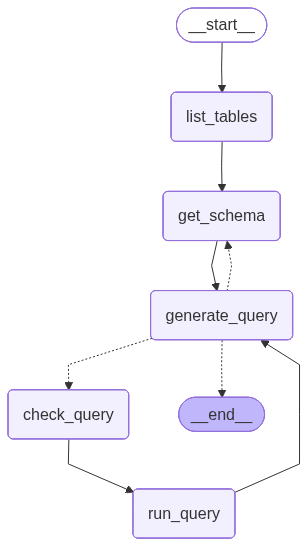

In [10]:
from IPython.display import Image, display

display(Image(sql_graph.get_graph().draw_mermaid_png()))

In [11]:
def format_messages_as_text(messages):
    lines = []

    for msg in messages:
        if isinstance(msg, dict):
            role = msg.get("role", "unknown")
            content = msg.get("content", "")
        else:
            msg_type = getattr(msg, "type", "unknown")
            content = getattr(msg, "content", "")

            if msg_type == "human":
                role = "user"
            elif msg_type == "ai":
                role = "assistant"
            else:
                role = msg_type

        lines.append(f"{role}: {content}")

    return "\n".join(lines)

def summarize(state: ParentState):
    if state.get("skip_summary", False):
        return {}
    
    messages = state.get("messages", [])
    latest_turn = messages[-2:] if len(messages) >= 2 else messages
    latest_turn_text = format_messages_as_text(latest_turn)
    old_summary = state.get("summary", "")
    
    summarize_prompt = f"""
    
        你是一个负责维护多轮对话记忆的模块。
        
        请基于【历史记忆】和【最新对话】，更新记忆。
        只保留对后续任务推进有价值的信息。
        
        记忆中只保留：
        - 用户当前目标
        - 已确认的关键信息
        - 用户偏好与限制
        - 尚未解决的问题
        - 下一步应做的事

        请遵守：
        - 不要复述原始对话
        - 不要保留寒暄、客套、重复内容
        - 若新旧信息冲突，以最新且明确确认的信息为准
        - 未确认内容单独标注，不要当作事实
        - 删除过时信息
        - 不要编造任何未出现的信息
        - 回答最多使用五句话，并保持简洁。

        【历史信息】
        {old_summary}

        【最新对话】
        {latest_turn_text}
        
    """
    
    summarize_history = llm.invoke([{"role": "user", "content": summarize_prompt}]).content.strip()
    
    print("-"*100)
    print("Summary")
    print(summarize_history)
    print("-"*100)
    
    return {
        "summary": summarize_history,
    }

In [12]:
class RouteDecision(BaseModel):
    route: Literal["sql", "clarify"] = Field(
        description="The routing decision for the user query."
    )
    reason: str = Field(
        description="One-sentence reason for the routing decision."
    )
    missing_slots: List[str] = Field(
        default_factory=list,
        description="Missing required slots such as company, period, metric. Empty list if none."
    )

def route_node(state: ParentState):
    question = state["real_query"]
    
    route_prompt = f"""
    
    你是一个上市公司财报智能问数助手的“路由器（Router）”。

    你的任务不是回答用户问题，而是判断这个问题应该走哪条处理链路。

    你只能输出以下两种 route：
    1. sql
       - 适用于可以主要通过结构化财务数据库回答的问题
       - 典型包括：数值查询、指标查询、同比/环比、趋势、排名、topN、筛选、排序、聚合统计、跨公司比较
    2. clarify
       - 适用于用户问题缺少关键条件，当前无法可靠执行
       - 例如缺少公司名、报告期、指标名、比较对象等
    
    判定原则：
    - 如果问题主要在问“多少、是否、排名、变化趋势、同比环比、topN、哪个最大/最小”，优先判为 sql
    - 如果问题缺少关键查询条件，判为 clarify

    请特别注意：
    - “趋势分析”“同比分析”“排名分析”通常仍然属于 sql

    示例1
    用户问题：比亚迪2025年三季度营业收入是多少？
    输出：
    {{
      "route": "sql",
      "reason": "这是明确的单指标单时期数值查询，可直接通过结构化财务数据库回答",
      "missing_slots": [],
    }}

    示例2
    用户问题：金花股份近几年的利润总额变化趋势是什么样的？
    输出：
    {{
      "route": "sql",
      "reason": "这是时间序列趋势分析问题，主要依赖结构化财务数据",
      "missing_slots": [],
    }}

    示例3
    用户问题：利润总额是多少？
    输出：
    {{
      "route": "clarify",
      "reason": "缺少公司和报告期，无法直接执行查询",
      "missing_slots": ["company", "period"],
    }}
    
    示例4
    用户问题：华为每股收益是多少？
    输出：
    {{
      "route": "clarify",
      "reason": "缺少报告期，无法直接执行查询",
      "missing_slots": ["period"],
    }}
    
    现在请判断下面这个用户问题：
    用户问题：{question}

    请严格输出 JSON，不要输出任何额外解释：
    
    {{
      "route": "sql | clarify",
      "reason": "一句话说明分类原因",
      "missing_slots": ["若无则输出空数组"],
    }}
    """
    structured_llm = llm.with_structured_output(RouteDecision)
    decision = structured_llm.invoke(route_prompt)
    
    return {
        "real_query": question,
        "route": decision.route,
        "reason": decision.reason,
        "missing_slots": decision.missing_slots,
        "need_sql": decision.route in ["sql", "hybrid"],
        "need_clarification": decision.route == "clarify",
        "final_answer": "",
    }
    
def route_function(state: ParentState):
    key = state.get("route")
    if key == "sql":
        return "sql_node"
    else:
        return "clarify"

In [13]:
def clarify(state: ParentState):
    question = state["real_query"]
    missing_slots = state.get("missing_slots", [])

    clarify_prompt = f"""
        你是一个上市公司财报智能问数助手。

        用户原始问题：
        {question}

        当前还缺少这些关键信息：
        {missing_slots}

        你的任务是：
        基于用户原始问题和缺失槽位，生成一句自然、简洁、礼貌的澄清问题，引导用户一次性补全所缺信息，以便继续查询。

        要求：
        1. 只输出一句面向用户的澄清问题，不要输出解释，不要输出 JSON，不要输出多余内容。
        2. 如果缺少多个槽位，尽量合并成一句话一起问，不要拆成多句。
        3. 语气自然，适合中文对话场景。
        4. 问法要贴合财报问数场景。
        
        示例1
        原始问题：利润总额是多少？
        缺失槽位：["company", "period"]
        输出：请问你想查询哪家公司，以及哪个报告期的利润总额？

        示例2
        原始问题：同比最高的是哪家？
        缺失槽位：["metric", "period", "ranking_scope"]
        输出：请问你想查询哪个指标、哪个报告期，以及希望在哪个范围内比较同比？

        示例3
        原始问题：原因是什么？
        缺失槽位：["explanation_target"]
        输出：请问你具体想了解哪个指标或现象变化的原因？
        """.strip()

    response = llm.invoke([{"role": "user", "content": clarify_prompt}])

    return {
        "messages": [AIMessage(content=response.content)],
        "final_answer": response.content,
        "need_clarification": True,
        "pending_clarification": True,
        "original_question": question,
        "missing_slots": missing_slots,
    }

In [14]:
import os
import re
import uuid
import pandas as pd
import matplotlib.pyplot as plt
from langgraph.checkpoint.memory import MemorySaver

plt.rcParams["font.sans-serif"] = ["SimHei", "Microsoft YaHei", "Arial Unicode MS", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

os.makedirs("./result", exist_ok=True)

PLOT_KEYWORDS = [
    "趋势", "走势", "变化", "可视化", "绘图", "画图",
    "折线图", "柱状图", "历年", "近年", "近三年", "近五年"
]

def should_plot(question: str) -> bool:
    return any(k in question for k in PLOT_KEYWORDS)

def extract_last_sql_query(messages):
    for msg in reversed(messages):
        tool_calls = getattr(msg, "tool_calls", None) or []
        for tc in tool_calls:
            if tc.get("name") == "sql_db_query":
                args = tc.get("args", {}) or {}
                sql_text = args if isinstance(args, str) else (
                    args.get("query") or
                    args.get("__arg1") or
                    args.get("input") or
                    args.get("sql")
                )
                if sql_text:
                    return sql_text
    return None

def period_sort_key(val):
    s = str(val).strip()
    m = re.match(r"(\d{4})(?:Q([1-4])|FY)", s)
    if not m:
        return (9999, 99, s)

    year = int(m.group(1))
    order = 5 if "FY" in s else int(m.group(2))
    return (year, order, s)

def pick_xy_columns(df):
    """
    自动找 x 轴和 y 轴：
    优先找 x_axis / y_axis，
    否则优先 report_period + 第一个可转成数值的列
    """
    x_candidates = ["x_axis", "report_period", "period", "日期", "年份", "year"]
    x_col = next((c for c in x_candidates if c in df.columns), df.columns[0])

    numeric_cols = []
    for c in df.columns:
        if c == x_col:
            continue
        series = pd.to_numeric(df[c], errors="coerce")
        if series.notna().any():
            numeric_cols.append(c)

    if not numeric_cols:
        raise ValueError(f"没有找到可绘图的数值列，当前列为: {list(df.columns)}")

    y_col = "y_axis" if "y_axis" in numeric_cols else numeric_cols[0]
    return x_col, y_col

def save_line_chart(df, question, out_dir="./result", prefix="chart"):
    if df is None or df.empty or len(df.columns) < 2:
        return []

    x_col, y_col = pick_xy_columns(df)

    plot_df = df[[x_col, y_col]].copy()
    plot_df[y_col] = pd.to_numeric(plot_df[y_col], errors="coerce")
    plot_df = plot_df.dropna(subset=[y_col])

    if plot_df.empty or len(plot_df) < 2:
        return []

    if x_col in ["x_axis", "report_period", "period"]:
        plot_df["_sort_key"] = plot_df[x_col].map(period_sort_key)
        plot_df = plot_df.sort_values("_sort_key").drop(columns=["_sort_key"])

    fig, ax = plt.subplots(figsize=(10, 4.5))
    ax.plot(plot_df[x_col].astype(str), plot_df[y_col], marker="o")
    ax.set_title(question)
    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)
    plt.xticks(rotation=45)
    plt.tight_layout()

    os.makedirs(out_dir, exist_ok=True)
    file_path = os.path.join(out_dir, f"{prefix}_{uuid.uuid4().hex[:8]}.png")
    plt.savefig(file_path, dpi=200, bbox_inches="tight")
    plt.close(fig)

    return [file_path]

In [15]:
def sql_node(state: ParentState):
    question = state["real_query"]

    result = sql_graph.invoke({
        "sql_messages": [{"role": "user", "content": question}],
        "real_query": question,
    })

    sql_messages = result["sql_messages"]
    last_msg = sql_messages[-1]
    answer = getattr(last_msg, "content", str(last_msg))

    sql_text = extract_last_sql_query(sql_messages)
    image_paths = []

    if sql_text and should_plot(question):
        try:
            df = pd.read_sql_query(sql_text, engine)
            image_paths = save_line_chart(
                df,
                question,
                out_dir="./result",
                prefix="sql_plot"
            )
        except Exception as e:
            print(f"[plot error] {e}")

    return {
        "messages": [last_msg],
        "sql_result": {
            "used": True,
            "success": True,
            "query": sql_text,  
            "answer": answer,
            "image_path": image_paths, 
        }
    }

In [16]:
workflow = StateGraph(ParentState)

workflow.add_node("route_node", route_node)
workflow.add_node("sql_node", sql_node)
workflow.add_node("clarify", clarify)

workflow.add_node("real_query", merge_query)
workflow.add_node("summarize", summarize)

workflow.add_edge(START, "real_query")

workflow.add_edge("real_query", "route_node")
workflow.add_conditional_edges(
    "route_node",
    route_function,
    {
        "sql_node": "sql_node",
        "clarify": "clarify",
    },
)
workflow.add_edge("sql_node", "summarize")

workflow.add_edge("clarify", "summarize")

workflow.add_edge("summarize", END)

checkpointer = MemorySaver()
graph = workflow.compile(checkpointer=checkpointer)

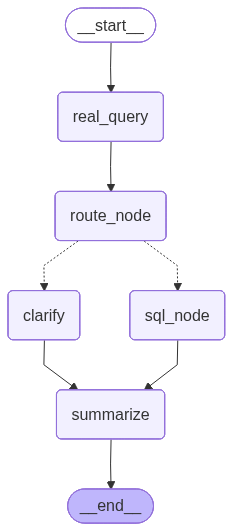

In [17]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [18]:
def format_qa_for_excel(qa_list):
    blocks = []
    for i, item in enumerate(qa_list, 1):
        q = item.get("Q", "")
        a = item.get("A", {}).get("content", "")
        blocks.append(f"Q{i}：{q}\nA{i}：{a}")
    return "\n\n".join(blocks)

def rename_images_for_row(image_list, row_id, start_index=1, out_dir="./result"):
    image_list = normalize_image_list(image_list)
    if not image_list:
        return [], start_index

    os.makedirs(out_dir, exist_ok=True)
    renamed_paths = []
    current_index = start_index

    for old_path in image_list:
        ext = os.path.splitext(old_path)[1] or ".png"
        new_name = f"{row_id}_{current_index}{ext}"
        new_path = os.path.join(out_dir, new_name)

        if os.path.abspath(old_path) != os.path.abspath(new_path):
            os.replace(old_path, new_path)

        renamed_paths.append(new_path)
        current_index += 1

    return renamed_paths, current_index

In [19]:
import ast
import json
import uuid
import pandas as pd


def parse_question_cell(cell):
    """
    解析 Excel 中“问题”列
    支持：
    1. 普通字符串
    2. JSON 字符串
    3. Python 列表字符串
    返回：问题列表，如 ["问题1", "问题2"]
    """
    if pd.isna(cell):
        return []

    if isinstance(cell, list):
        raw = cell
    else:
        text = str(cell).strip()
        if not text:
            return []

        text = (
            text.replace("“", '"')
                .replace("”", '"')
                .replace("‘", "'")
                .replace("’", "'")
        )

        if text.startswith("[") and text.endswith("]"):
            try:
                raw = json.loads(text)
            except Exception:
                raw = ast.literal_eval(text)
        else:
            return [text]

    questions = []
    for item in raw:
        if isinstance(item, dict):
            q = item.get("Q") or item.get("q") or item.get("question")
            if q and str(q).strip():
                questions.append(str(q).strip())
        elif isinstance(item, str):
            if item.strip():
                questions.append(item.strip())

    return questions


def normalize_image_list(x):
    """
    统一把 image / image_path 转成 list[str]
    """
    if x is None:
        return []
    if isinstance(x, list):
        return [str(i) for i in x if str(i).strip()]
    if isinstance(x, str):
        s = x.strip()
        if not s:
            return []
        try:
            val = json.loads(s)
            if isinstance(val, list):
                return [str(i) for i in val if str(i).strip()]
            return [s]
        except Exception:
            return [s]
    return []


def detect_chart_type(question, image_list):
    """
    根据问题内容和是否有图，给出图形格式
    你现在先用最简单稳定的规则：
    - 没图：无
    - 有图且问题包含趋势/走势/变化：折线图
    - 有图且问题包含占比/构成：饼图
    - 其他有图：图表
    """
    if not image_list:
        return "无"

    q = str(question)
    if any(k in q for k in ["趋势", "走势", "变化", "历年", "近几年", "近年"]):
        return "折线图"
    if any(k in q for k in ["占比", "构成"]):
        return "饼图"
    if any(k in q for k in ["对比", "比较", "排名"]):
        return "柱状图"

    return "图表"

import re

def markdown_to_plain_text(text: str) -> str:
    if not text:
        return ""

    text = str(text).replace("\r\n", "\n")

    # 去掉粗体、标题、行内代码
    text = text.replace("**", "").replace("__", "")
    text = re.sub(r"`([^`]*)`", r"\1", text)
    text = re.sub(r"^\s{0,3}#{1,6}\s*", "", text, flags=re.M)

    # 去掉列表符号
    text = re.sub(r"^\s*[-*+]\s+", "", text, flags=re.M)

    lines = text.split("\n")
    result = []
    i = 0

    while i < len(lines):
        line = lines[i].strip()

        # 识别 markdown 表格
        if line.startswith("|") and line.endswith("|"):
            table_block = []
            while i < len(lines):
                cur = lines[i].strip()
                if cur.startswith("|") and cur.endswith("|"):
                    table_block.append(cur)
                    i += 1
                else:
                    break

            # 表头 + 分隔线 + 数据
            if len(table_block) >= 3:
                headers = [x.strip() for x in table_block[0].strip("|").split("|")]
                for row in table_block[2:]:
                    cells = [x.strip() for x in row.strip("|").split("|")]
                    if len(cells) == len(headers):
                        result.append("，".join(f"{h}：{c}" for h, c in zip(headers, cells)))
            else:
                # 不是标准表格时，粗暴去掉 |
                for row in table_block:
                    row = row.replace("|", " ").strip()
                    if row:
                        result.append(row)
            continue

        # 跳过表格分隔线
        if re.fullmatch(r"\|?[\-\:\s\|]+\|?", line):
            i += 1
            continue

        if line:
            # 顺手把多余的 | 去掉
            line = line.replace("|", " ")
            result.append(line)

        i += 1

    return "\n".join(result).strip()

def run_one_turn(question, thread_id, question_count=1):
    """
    执行单轮问答，并提取当前轮需要写入 Excel 的核心信息
    """
    skip_summary = (question_count == 1)

    config = {"configurable": {"thread_id": thread_id}}
    inputs = {
        "messages": [
            {
                "role": "user",
                "content": question,
            }
        ],
        "query": question,
        "question_count": question_count,
        "skip_summary": skip_summary,
    }

    for _ in graph.stream(inputs, config):
        pass

    state = graph.get_state(config).values

    sql_result = state.get("sql_result") or {}

    sql_query = (
        sql_result.get("query")
        or sql_result.get("sql")
        or state.get("sql_query")
        or ""
    )

    answer_text = (
        state.get("final_answer")
        or sql_result.get("answer")
        or rag_result.get("answer")
        or ""
    )
    
    answer_text = markdown_to_plain_text(answer_text)

    image_list = normalize_image_list(
        sql_result.get("image_path")
    )

    answer_obj = {
        "content": answer_text
    }
    if image_list:
        answer_obj["image"] = image_list

    return {
        "Q": question,
        "A": answer_obj,
        "route": state.get("route", ""),
        "sql_query": sql_query,
        "image_list": image_list,
    }


def run_excel_batch(
    xlsx_path,
    sheet_name=0,
    id_col="编号",
    question_col="问题",
    output_path="./result/批量问答结果.xlsx"
):
    """
    输出格式与截图一致：
    编号 | 问题 | SQL 查询语句 | 图形格式 | 回答
    """
    df = pd.read_excel(xlsx_path, sheet_name=sheet_name)
    df.columns = [str(c).strip() for c in df.columns]

    if id_col not in df.columns:
        raise ValueError(f"Excel 中未找到列：{id_col}，当前列名：{df.columns.tolist()}")
    if question_col not in df.columns:
        raise ValueError(f"Excel 中未找到列：{question_col}，当前列名：{df.columns.tolist()}")

    batch_tag = uuid.uuid4().hex[:8]
    result_rows = []

    for _, row in df.iterrows():
        row_id = str(row[id_col]).strip()
        question_list = parse_question_cell(row[question_col])

        if not question_list:
            result_rows.append({
                "编号": row_id,
                "问题": "",
                "SQL 查询语句": "",
                "图形格式": "无",
                "回答": "",
            })
            continue

        thread_id = f"excel_{batch_tag}_{row_id}"

        qa_list = []
        last_sql = ""
        final_images = []
        image_counter = 1

        try:
            question_count = len(question_list)

            for q in question_list:
                turn_result = run_one_turn(
                    q,
                    thread_id,
                    question_count=question_count
                )

                if turn_result["sql_query"]:
                    last_sql = turn_result["sql_query"]

                if turn_result["image_list"]:
                    renamed_images, image_counter = rename_images_for_row(
                        turn_result["image_list"],
                        row_id=row_id,
                        start_index=image_counter,
                        out_dir="./result"
                    )

                    # 把当前轮返回的图片路径改成重命名后的路径
                    turn_result["image_list"] = renamed_images

                    # 同时把写入“回答”里的 image 字段也改掉
                    if "A" in turn_result and isinstance(turn_result["A"], dict):
                        turn_result["A"]["image"] = renamed_images

                    final_images = renamed_images
                    
                qa_list.append({
                    "Q": turn_result["Q"],
                    "A": turn_result["A"]
                })

            chart_type = detect_chart_type(
                question=" ".join(question_list),
                image_list=final_images
            )

            result_rows.append({
                "编号": row_id,
                "问题": json.dumps([{"Q": q} for q in question_list], ensure_ascii=False),
                "SQL 查询语句": last_sql,
                "图形格式": chart_type,
                "回答": json.dumps(qa_list, ensure_ascii=False, indent=2),
            })

        except Exception as e:
            result_rows.append({
                "编号": row_id,
                "问题": json.dumps([{"Q": q} for q in question_list], ensure_ascii=False),
                "SQL 查询语句": "",
                "图形格式": "无",
                "回答": json.dumps(
                    [{"Q": "系统异常", "A": {"content": str(e)}}],
                    ensure_ascii=False
                ),
            })

    result_df = pd.DataFrame(result_rows)
    result_df.to_excel(output_path, index=False)
    print(f"批量问答完成，结果保存到：{output_path}")
    return result_df

In [ ]:
import time

start = time.time()

result_df = run_excel_batch(
    xlsx_path=r"示例数据\附件4：问题汇总.xlsx",
    sheet_name=0,
    id_col="编号",
    question_col="问题",
    output_path=r"示例数据\任务二批量问答结果.xlsx"
)

end = time.time()
print("运行时间：", end - start, "秒")